# APIS Synthetic Dataset EDA

Exploratory analysis of generated synthetic student data.

In [1]:
import sys
from pathlib import Path

# Add project root (APIS/) to sys.path so backend/ and data_generation/ are importable
project_root = Path.cwd().parent  # notebooks/ -> APIS/
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/synthetic_dataset.csv")  # notebook is in notebooks/, so go up one level
print(f"Loaded {len(df)} rows, {df['student_id'].nunique()} students")
from backend.schemas import FEATURE_COLUMNS, TARGET_NEXT_GPA, TARGET_FINAL_CGPA, TARGET_GRADUATION_CLASS, TARGET_ACADEMIC_RISK

Loaded 994 rows, 100 students


In [9]:
print(df['graduation_class'].value_counts())

graduation_class
Second Class Upper    23012
Second Class Lower    19192
Third Class            4390
First Class            3198
Pass                    136
Name: count, dtype: int64


In [3]:
from data_generation.generator import generate_dataset
rows = generate_dataset(n_students=5000, programme_durations=[4,5,6], seed=42)
df = pd.DataFrame([r.model_dump() for r in rows])
print(f"Shape: {df.shape}")
print(f"Students: {df['student_id'].nunique()}")
df.head()

Shape: (49928, 25)
Students: 5000


,student_id,university,faculty,department,course,gpa_scale,programme_duration_years,current_level,semester_number,academic_session,...,semesters_remaining,is_final_semester,gpa_trend_slope,gpa_volatility,recent_gpa_avg_3,credits_velocity,next_semester_gpa,final_cgpa,graduation_class,academic_risk
0,STU_0000,University of Lagos,Science,Mathematics,Mathematics,5.0,6,100,1,2020/2021,...,11,False,0.000000,0.000000,4.290697,19.00,4.52,4.43,Second Class Upper,Low
1,STU_0000,University of Lagos,Science,Mathematics,Mathematics,5.0,6,100,2,2020/2021,...,10,False,0.230271,0.162826,4.405832,19.00,4.39,4.43,Second Class Upper,Low
2,STU_0000,University of Lagos,Science,Mathematics,Mathematics,5.0,6,200,3,2021/2022,...,9,False,0.050618,0.115415,4.401200,19.00,4.43,4.43,Second Class Upper,Low
3,STU_0000,University of Lagos,Science,Mathematics,Mathematics,5.0,6,200,4,2021/2022,...,8,False,0.028345,0.095197,4.447031,18.75,4.55,4.43,Second Class Upper,Low
4,STU_0000,University of Lagos,Science,Mathematics,Mathematics,5.0,6,300,5,2022/2023,...,7,False,0.042154,0.103498,4.455994,18.80,4.42,4.43,Second Class Upper,Low


In [4]:
df.describe(include='all')

,student_id,university,faculty,department,course,gpa_scale,programme_duration_years,current_level,semester_number,academic_session,...,semesters_remaining,is_final_semester,gpa_trend_slope,gpa_volatility,recent_gpa_avg_3,credits_velocity,next_semester_gpa,final_cgpa,graduation_class,academic_risk
count,49928,49928,49928,49928,49928,49928.0,49928.000000,49928.000000,49928.000000,49928,...,49928.000000,49928,49928.000000,49928.000000,49928.000000,49928.000000,44928.000000,49928.000000,49928,49928
unique,5000,5,5,25,25,NaN,NaN,NaN,NaN,10,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,5,3
top,STU_0000,University of Ibadan,Medical Sciences,Biology,Cell Biology,NaN,NaN,NaN,NaN,2024/2025,...,NaN,False,NaN,NaN,NaN,NaN,NaN,NaN,Second Class Upper,Low
freq,12,10498,10278,2250,2250,NaN,NaN,NaN,NaN,9370,...,NaN,44928,NaN,NaN,NaN,NaN,NaN,NaN,23012,37105
mean,NaN,NaN,NaN,NaN,NaN,5.0,5.124419,299.711585,5.624419,NaN,...,4.624419,NaN,0.001083,0.306636,3.478665,19.131892,3.479204,3.478506,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,0.0,0.800774,141.320470,3.086268,NaN,...,3.086268,NaN,0.215429,0.217978,0.757358,1.154886,0.828609,0.721123,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,5.0,4.000000,100.000000,1.000000,NaN,...,0.000000,NaN,-2.290272,0.000000,0.343862,16.083333,0.000000,1.080000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,5.0,4.000000,200.000000,3.000000,NaN,...,2.000000,NaN,-0.058821,0.155991,2.985393,18.250000,2.940000,3.010000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,5.0,5.000000,300.000000,5.000000,NaN,...,4.000000,NaN,0.000000,0.271594,3.547126,19.000000,3.560000,3.540000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,5.0,6.000000,400.000000,8.000000,NaN,...,7.000000,NaN,0.060275,0.434777,4.042875,20.000000,4.090000,4.020000,NaN,NaN


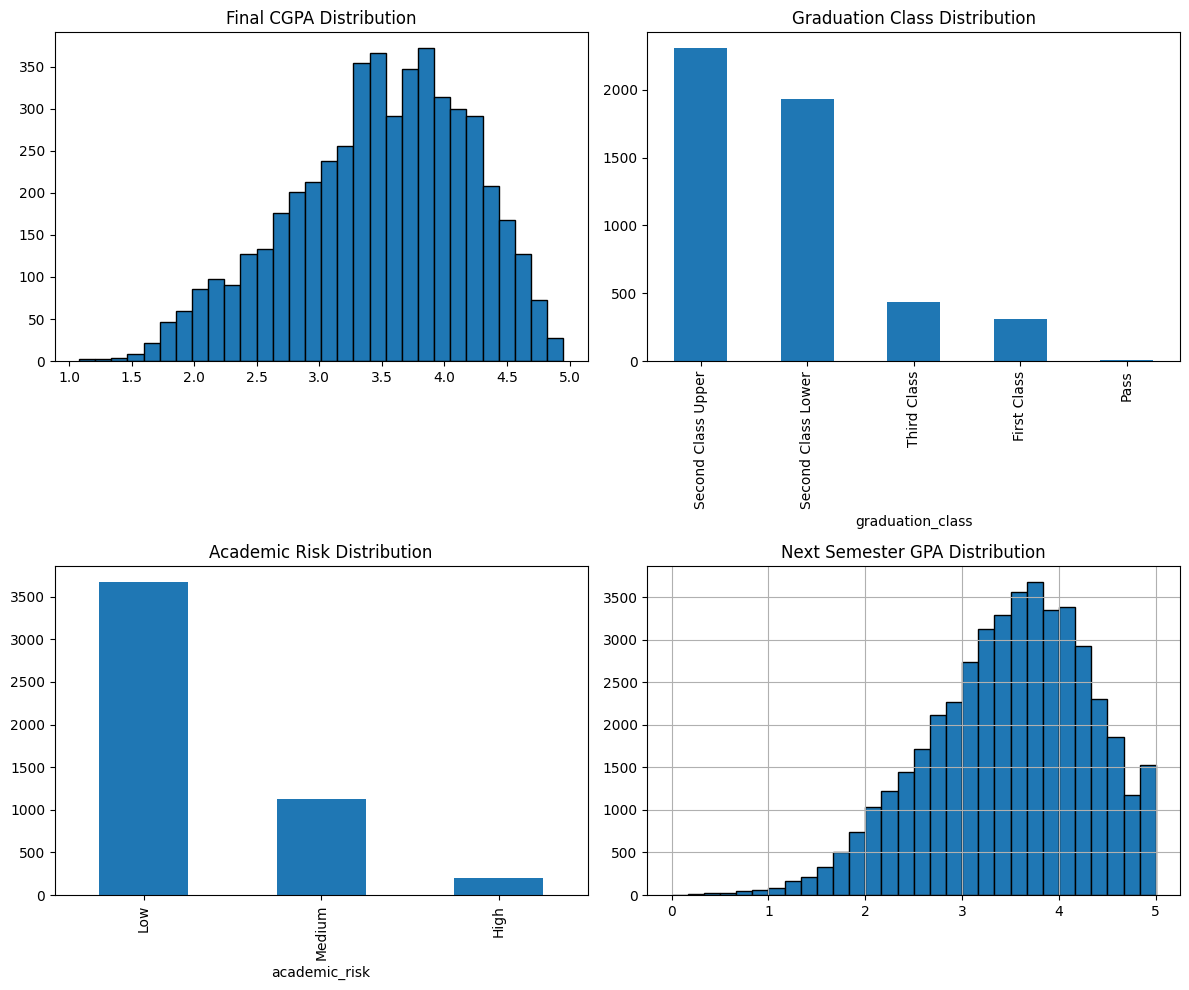

In [5]:
# Target distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
df_final = df[df['is_final_semester']]

axes[0,0].hist(df_final['final_cgpa'].dropna(), bins=30, edgecolor='black')
axes[0,0].set_title('Final CGPA Distribution')

df_final['graduation_class'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Graduation Class Distribution')

df_final['academic_risk'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Academic Risk Distribution')

df[df['semester_number'] < df.groupby('student_id')['semester_number'].transform('max')]['next_semester_gpa'].hist(bins=30, ax=axes[1,1], edgecolor='black')
axes[1,1].set_title('Next Semester GPA Distribution')
plt.tight_layout()
plt.show()

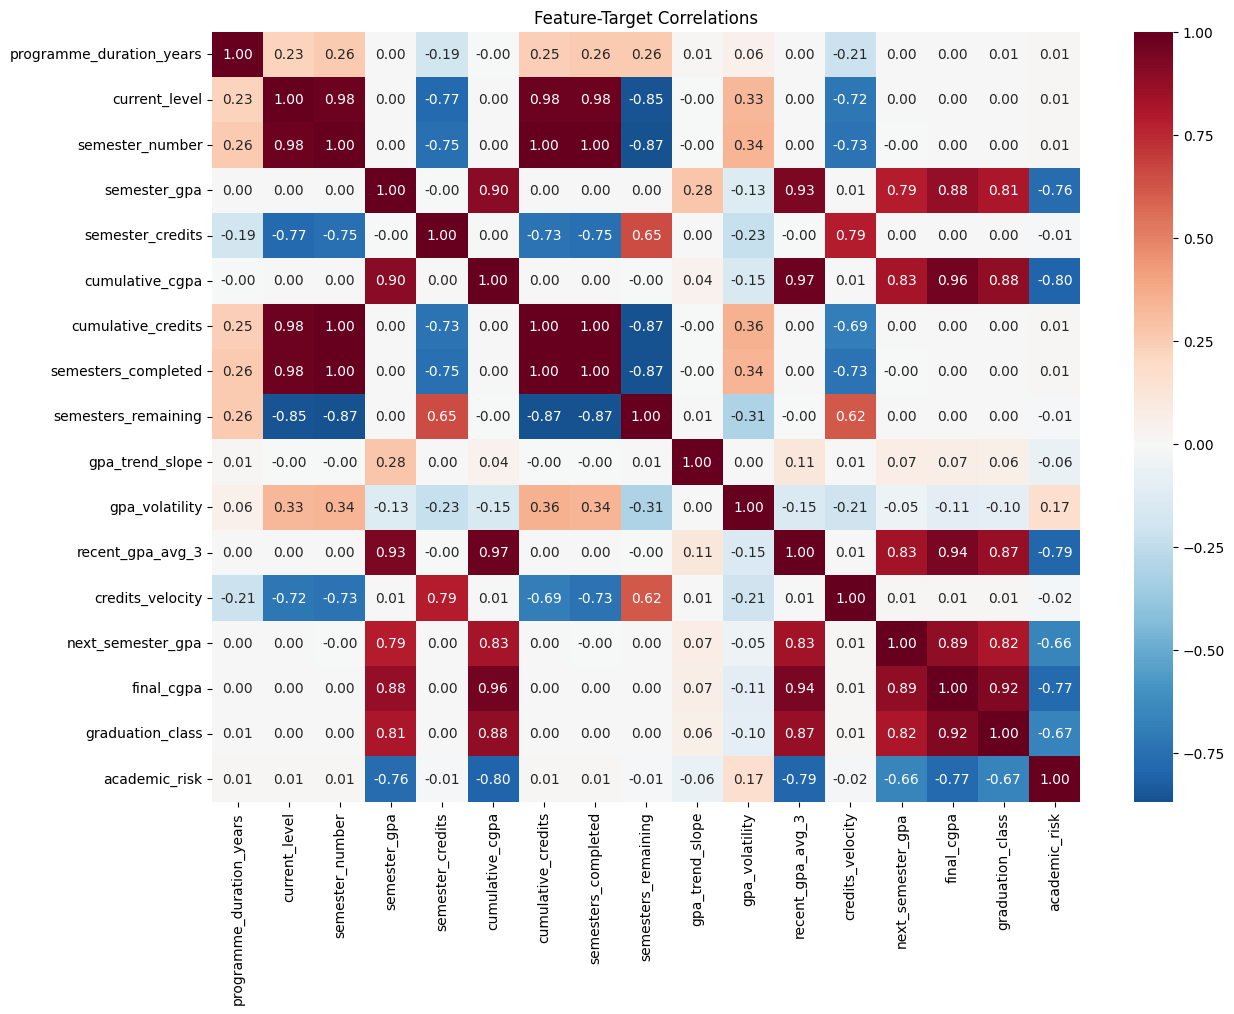

In [6]:
# Feature correlations with targets
feature_cols = FEATURE_COLUMNS
targets = [TARGET_NEXT_GPA, TARGET_FINAL_CGPA, TARGET_GRADUATION_CLASS, TARGET_ACADEMIC_RISK]

# Encode categorical targets for correlation
df_enc = df.copy()
df_enc[TARGET_GRADUATION_CLASS] = pd.Categorical(df_enc[TARGET_GRADUATION_CLASS], 
    categories=['Fail', 'Pass', 'Third Class', 'Second Class Lower', 'Second Class Upper', 'First Class']).codes
df_enc[TARGET_ACADEMIC_RISK] = pd.Categorical(df_enc[TARGET_ACADEMIC_RISK], 
    categories=['Low', 'Medium', 'High']).codes

corr_matrix = df_enc[feature_cols + targets].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Feature-Target Correlations')
plt.show()

In [7]:
# Class balance check
print('Graduation Class Balance:')
print(df_final['graduation_class'].value_counts(normalize=True))
print()
print('Academic Risk Balance:')
print(df_final['academic_risk'].value_counts(normalize=True))

Graduation Class Balance:
graduation_class
Second Class Upper    0.4616
Second Class Lower    0.3864
Third Class           0.0870
First Class           0.0626
Pass                  0.0024
Name: proportion, dtype: float64

Academic Risk Balance:
academic_risk
Low       0.7348
Medium    0.2246
High      0.0406
Name: proportion, dtype: float64


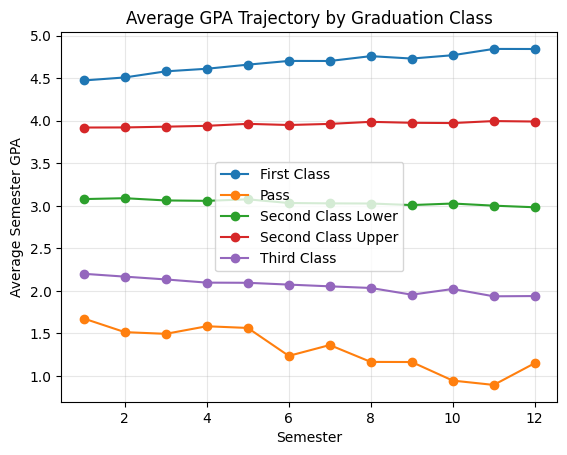

In [8]:
# Trajectory patterns
# Average GPA trajectory by graduation class
traj = df.groupby(['student_id', 'semester_number'])['semester_gpa'].mean().reset_index()
traj = traj.merge(df_final[['student_id', 'graduation_class']], on='student_id')

for cls in sorted(df_final['graduation_class'].unique()):
    subset = traj[traj['graduation_class'] == cls]
    avg_traj = subset.groupby('semester_number')['semester_gpa'].mean()
    plt.plot(avg_traj.index, avg_traj.values, label=cls, marker='o')
plt.xlabel('Semester')
plt.ylabel('Average Semester GPA')
plt.title('Average GPA Trajectory by Graduation Class')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()